# Amazon Reviews 2023 — Exploratory Data Analysis

Dataset: [McAuley-Lab/Amazon-Reviews-2023](https://amazon-reviews-2023.github.io/)

**Categories analyzed:** All_Beauty, Video_Games, Electronics, Books

**Analyses:**
1. Reviews per item — P20/P50/P90/P99
2. Reviews per user — P20/P50/P90/P99
3. Filtering impact at various thresholds
4. Bought-together hit rate
5. Cross-category browsing overlap
6. Rating & engagement distributions

In [1]:
import sys
sys.path.insert(0, "/path/to/R-project")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from scripts.data.download import download_category
from scripts.data.loader import stream_stats, load_sampled, load_metadata
from scripts.data.preprocessing import (
    filter_by_counts,
    compute_filtering_table,
    compute_bought_together_hit_rate,
    cross_category_users,
)

CATEGORIES = ["All_Beauty", "Video_Games", "Books", "Electronics"]
FIGURES_DIR = Path("/path/to/R-project/figures")
RESULTS_DIR = Path("/path/to/R-project/results")
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

/home/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 0: Download datasets

Download All_Beauty in full; sample 1M rows for large categories.

In [2]:
# Download all categories (full for both — small enough)
download_limits = {
    "All_Beauty": None,       # 701K — full
    "Video_Games": None,      # 4.6M — full
}

for cat, limit in download_limits.items():
    download_category(cat, max_rows=limit)

[download] Reviews already exist: /path/to/R-project/data/raw/All_Beauty/reviews.parquet
[download] Metadata already exists: /path/to/R-project/data/raw/All_Beauty/metadata.parquet
[download] Reviews already exist: /path/to/R-project/data/raw/Video_Games/reviews.parquet
[download] Metadata already exists: /path/to/R-project/data/raw/Video_Games/metadata.parquet


## Step 1: Stream statistics for all categories

Stream through the full JSONL files (not the sampled parquets) to get accurate population statistics. This is memory-efficient — only stores per-item and per-user count dictionaries.

In [3]:
# Stream full statistics for each category
# For large categories this streams the full JSONL — may take 20-30 min each
all_stats = {}
for cat in CATEGORIES:
    save_path = RESULTS_DIR / f"stream_stats_{cat}.json"
    print(f"\n{'='*60}")
    print(f"Streaming {cat}...")
    all_stats[cat] = stream_stats(cat, save_path=save_path)
    print(f"  Total reviews: {all_stats[cat]['total_reviews']:,}")
    print(f"  Unique items:  {all_stats[cat]['n_unique_items']:,}")
    print(f"  Unique users:  {all_stats[cat]['n_unique_users']:,}")


Streaming All_Beauty...
[stream_stats] Reading parquet for All_Beauty -> /path/to/R-project/data/raw/All_Beauty/reviews.parquet


[stream_stats] Summary saved -> /path/to/R-project/results/stream_stats_All_Beauty.json
  Total reviews: 701,528
  Unique items:  112,565
  Unique users:  631,986

Streaming Video_Games...
[stream_stats] Reading parquet for Video_Games -> /path/to/R-project/data/raw/Video_Games/reviews.parquet


[stream_stats] Summary saved -> /path/to/R-project/results/stream_stats_Video_Games.json
  Total reviews: 1,000,000
  Unique items:  81,952
  Unique users:  448,679

Streaming Books...
[stream_stats] Reading parquet for Books -> /path/to/R-project/data/raw/Books/reviews.parquet


[stream_stats] Summary saved -> /path/to/R-project/results/stream_stats_Books.json
  Total reviews: 1,000,000
  Unique items:  504,564
  Unique users:  165,531

Streaming Electronics...
[stream_stats] Reading parquet for Electronics -> /path/to/R-project/data/raw/Electronics/reviews.parquet


[stream_stats] Summary saved -> /path/to/R-project/results/stream_stats_Electronics.json
  Total reviews: 1,000,000
  Unique items:  271,211
  Unique users:  185,242


## Analysis 1: Reviews per Item — Percentiles & Distribution

In [4]:
# Compute percentiles for reviews per item
percentiles = [20, 50, 90, 99]
item_pct_rows = []
for cat in CATEGORIES:
    vals = np.array(list(all_stats[cat]["item_counts"].values()))
    row = {"category": cat, "n_items": len(vals), "mean": vals.mean()}
    for p in percentiles:
        row[f"P{p}"] = np.percentile(vals, p)
    item_pct_rows.append(row)

item_pct_df = pd.DataFrame(item_pct_rows).set_index("category")
item_pct_df.to_csv(RESULTS_DIR / "item_review_percentiles.csv")
print("Reviews per Item — Percentiles")
item_pct_df

Reviews per Item — Percentiles


,n_items,mean,P20,P50,P90,P99
category,,,,,,
All_Beauty,112565,6.232204,1.0,2.0,11.0,73.00
Video_Games,81952,12.202265,1.0,2.0,20.0,178.49
Books,504564,1.981909,1.0,1.0,3.0,14.00
Electronics,271211,3.687166,1.0,1.0,6.0,38.00


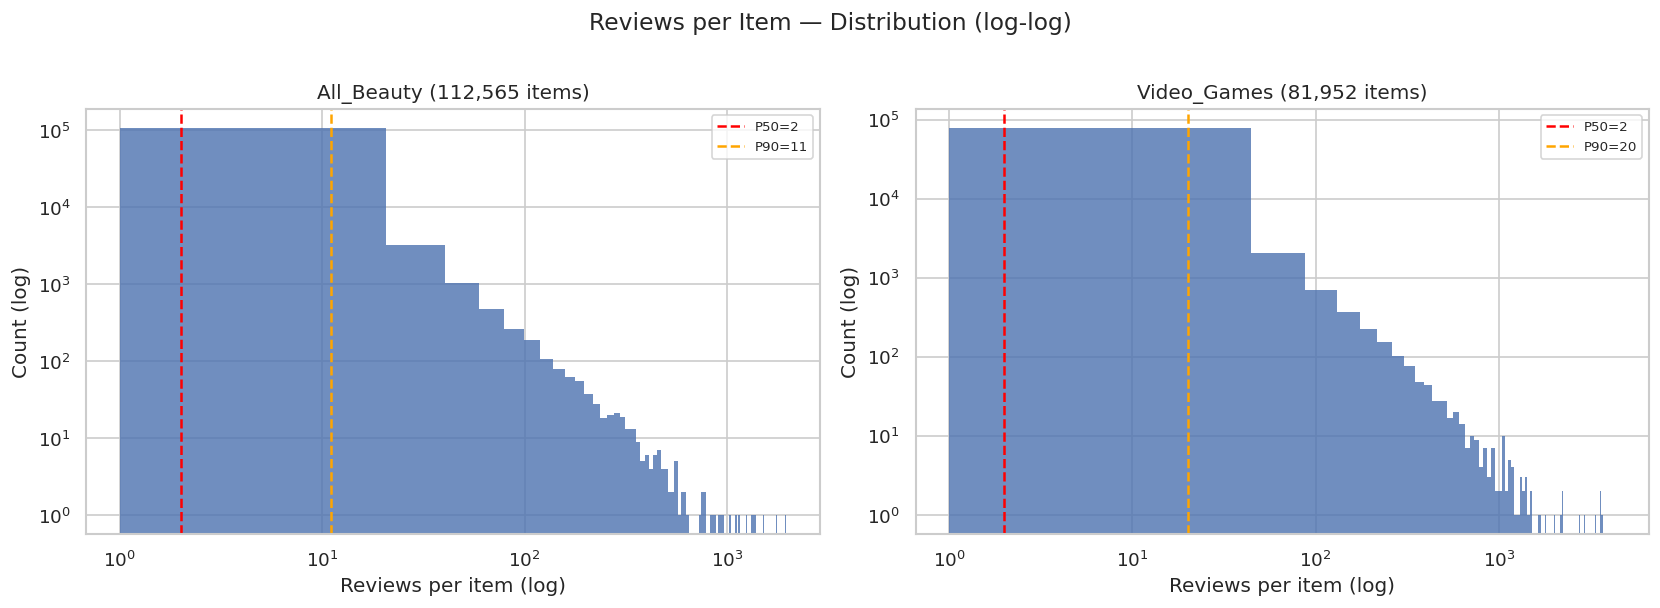

In [5]:
# Plot: Distribution of reviews per item (log-scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cat in zip(axes.flat, CATEGORIES):
    vals = np.array(list(all_stats[cat]["item_counts"].values()))
    ax.hist(vals, bins=100, log=True, edgecolor="none", alpha=0.8)
    ax.set_xscale("log")
    ax.set_title(f"{cat} ({len(vals):,} items)")
    ax.set_xlabel("Reviews per item (log)")
    ax.set_ylabel("Count (log)")
    # Mark P50, P90
    p50 = np.percentile(vals, 50)
    p90 = np.percentile(vals, 90)
    ax.axvline(p50, color="red", ls="--", label=f"P50={p50:.0f}")
    ax.axvline(p90, color="orange", ls="--", label=f"P90={p90:.0f}")
    ax.legend(fontsize=8)

fig.suptitle("Reviews per Item — Distribution (log-log)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "item_review_distribution.png", bbox_inches="tight")
plt.show()

## Analysis 2: Reviews per User — Percentiles & Distribution

In [6]:
# Compute percentiles for reviews per user
user_pct_rows = []
for cat in CATEGORIES:
    vals = np.array(list(all_stats[cat]["user_counts"].values()))
    row = {"category": cat, "n_users": len(vals), "mean": vals.mean()}
    for p in percentiles:
        row[f"P{p}"] = np.percentile(vals, p)
    user_pct_rows.append(row)

user_pct_df = pd.DataFrame(user_pct_rows).set_index("category")
user_pct_df.to_csv(RESULTS_DIR / "user_review_percentiles.csv")
print("Reviews per User — Percentiles")
user_pct_df

Reviews per User — Percentiles


,n_users,mean,P20,P50,P90,P99
category,,,,,,
All_Beauty,631986,1.110037,1.0,1.0,1.0,3.0
Video_Games,448679,2.228765,1.0,1.0,4.0,15.0
Books,165531,6.041164,1.0,2.0,11.0,59.0
Electronics,185242,5.398344,1.0,3.0,12.0,44.0


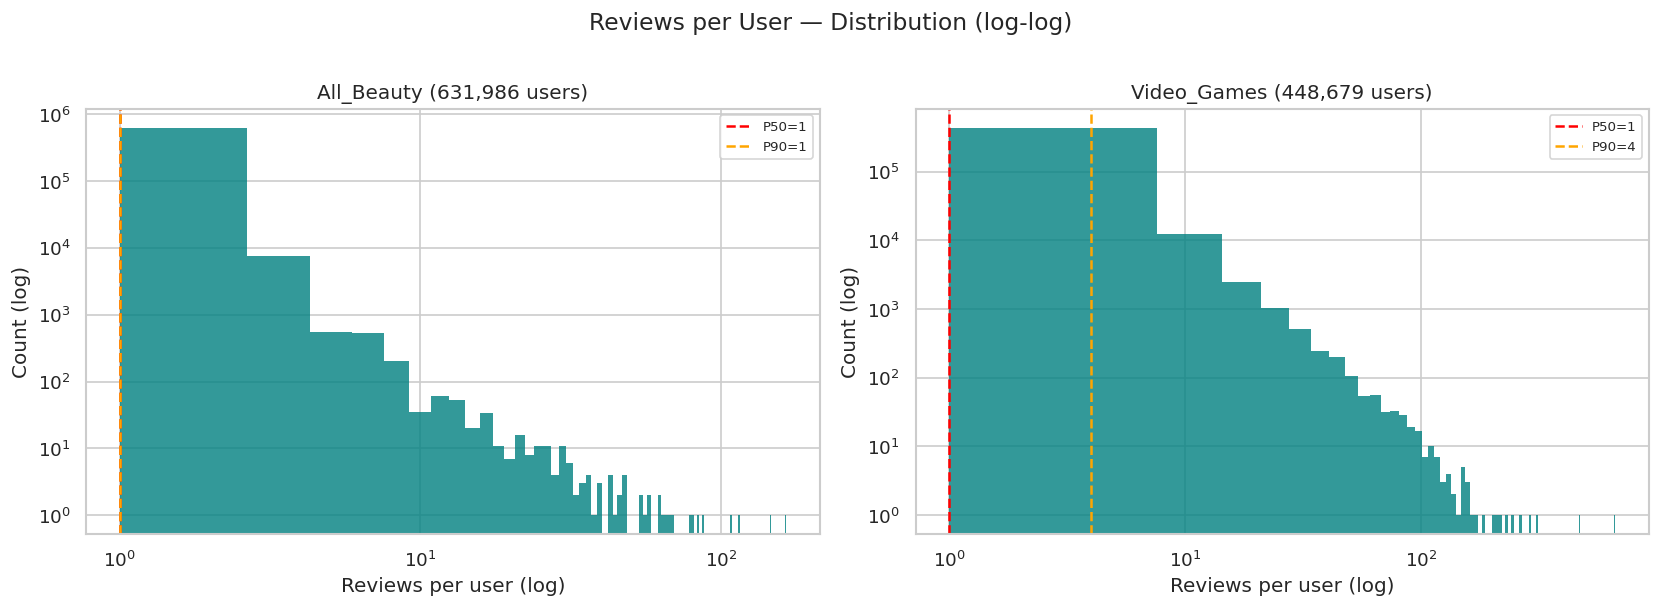

In [7]:
# Plot: Distribution of reviews per user (log-scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cat in zip(axes.flat, CATEGORIES):
    vals = np.array(list(all_stats[cat]["user_counts"].values()))
    ax.hist(vals, bins=100, log=True, edgecolor="none", alpha=0.8, color="teal")
    ax.set_xscale("log")
    ax.set_title(f"{cat} ({len(vals):,} users)")
    ax.set_xlabel("Reviews per user (log)")
    ax.set_ylabel("Count (log)")
    p50 = np.percentile(vals, 50)
    p90 = np.percentile(vals, 90)
    ax.axvline(p50, color="red", ls="--", label=f"P50={p50:.0f}")
    ax.axvline(p90, color="orange", ls="--", label=f"P90={p90:.0f}")
    ax.legend(fontsize=8)

fig.suptitle("Reviews per User — Distribution (log-log)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "user_review_distribution.png", bbox_inches="tight")
plt.show()

## Analysis 3: Filtering Impact

Estimate how many items, users, and reviews survive at various min-count thresholds.
- Item thresholds: [3, 5, 10]
- User thresholds: [3, 5]

In [8]:
# Estimate filtering impact from streamed count dictionaries (upper-bound)
filter_results = {}
for cat in CATEGORIES:
    ft = compute_filtering_table(all_stats[cat])
    ft["category"] = cat
    filter_results[cat] = ft

filter_df = pd.concat(filter_results.values(), ignore_index=True)
filter_df = filter_df[["category", "item_thresh", "user_thresh", "n_items", "n_users", "est_reviews"]]
filter_df.to_csv(RESULTS_DIR / "filtering_impact.csv", index=False)

# Display as a pivot for readability
for cat in CATEGORIES:
    subset = filter_df[filter_df["category"] == cat].drop(columns="category")
    print(f"\n{cat}")
    print(subset.to_string(index=False))


All_Beauty
 item_thresh  user_thresh  n_items  n_users  est_reviews
           3            3    45125     9159       614214
           3            5    45125     1620       614214
           5            3    27533     9159       554708
           5            5    27533     1620       554708
          10            3    13257     9159       462262
          10            5    13257     1620       462262

Video_Games
 item_thresh  user_thresh  n_items  n_users  est_reviews
           3            3    38627    93569       944140
           3            5    38627    39830       944140
           5            3    26787    93569       903889
           5            5    26787    39830       903889
          10            3    15562    93569       830307
          10            5    15562    39830       830307

Books
 item_thresh  user_thresh  n_items  n_users  est_reviews
           3            3    71214    73451       497360
           3            5    71214    45364       497360

In [9]:
# Verify with actual iterative core-filtering on All_Beauty (full data, fast)
df_beauty = load_sampled("All_Beauty")
print(f"Original: {len(df_beauty):,} reviews")

for min_item, min_user in [(5, 3), (10, 5)]:
    filtered = filter_by_counts(df_beauty, min_item_reviews=min_item, min_user_reviews=min_user)
    n_items = filtered["parent_asin"].nunique()
    n_users = filtered["user_id"].nunique()
    print(f"  min_item={min_item}, min_user={min_user}: "
          f"{len(filtered):,} reviews, {n_items:,} items, {n_users:,} users")

[load_sampled] Reading from /path/to/R-project/data/raw/All_Beauty/reviews.parquet


[load_sampled] Loaded 701,528 rows from All_Beauty
Original: 701,528 reviews


  min_item=5, min_user=3: 7,090 reviews, 914 items, 1,094 users


  min_item=10, min_user=5: 21 reviews, 2 items, 3 users


## Analysis 4: Bought-Together Hit Rate

For each user, check if any pair of items they reviewed appears in each other's `bought_together` list. Report:
- **Raw hit rate**: fraction of all users
- **Conditional hit rate**: fraction of users who reviewed items that have non-empty `bought_together`

In [10]:
# Compute bought-together hit rate for each category
# Note: bought_together field is empty/string '[]' in both categories.
# We check and report this rather than crashing on large datasets.
bt_results = {}
for cat in CATEGORIES:
    print(f"\n{'='*40} {cat}")
    meta = load_metadata(cat, columns=["parent_asin", "bought_together"])
    # Check if bought_together has any real data
    has_bt = meta["bought_together"].apply(
        lambda x: isinstance(x, list) and len(x) > 0
    ).sum()
    if has_bt == 0:
        # Try parsing string representations
        import ast
        def _parse_bt(x):
            if isinstance(x, str):
                try:
                    parsed = ast.literal_eval(x)
                    return isinstance(parsed, list) and len(parsed) > 0
                except:
                    return False
            return False
        has_bt = meta["bought_together"].apply(_parse_bt).sum()
    print(f"  Items with non-empty bought_together: {has_bt:,} / {len(meta):,}")
    if has_bt == 0:
        print("  -> Skipping hit rate (no bought_together data)")
        bt_results[cat] = {
            "n_users_total": 0, "n_users_with_bt_items": 0,
            "n_users_hit": 0, "hit_rate": 0.0, "hit_rate_conditional": 0.0,
            "note": "bought_together field is empty"
        }
    else:
        reviews = load_sampled(cat)
        bt = compute_bought_together_hit_rate(reviews, meta)
        bt_results[cat] = bt
        print(f"  Raw hit rate:          {bt['hit_rate']:.4f}")
        print(f"  Conditional hit rate:  {bt['hit_rate_conditional']:.4f}")
    del meta

bt_df = pd.DataFrame(bt_results).T
bt_df.to_csv(RESULTS_DIR / "bought_together_hit_rate.csv")
bt_df


======================================== All_Beauty
[load_metadata] Reading from /path/to/R-project/data/raw/All_Beauty/metadata.parquet
[load_metadata] Loaded 112,590 items for All_Beauty
  Items with non-empty bought_together: 0 / 112,590
  -> Skipping hit rate (no bought_together data)

======================================== Video_Games
[load_metadata] Reading from /path/to/R-project/data/raw/Video_Games/metadata.parquet


[load_metadata] Loaded 137,269 items for Video_Games


  Items with non-empty bought_together: 0 / 137,269
  -> Skipping hit rate (no bought_together data)

======================================== Books
[load_metadata] Reading from /path/to/R-project/data/raw/Books/metadata.parquet


[load_metadata] Loaded 4,448,181 items for Books


  Items with non-empty bought_together: 0 / 4,448,181
  -> Skipping hit rate (no bought_together data)

======================================== Electronics
[load_metadata] Reading from /path/to/R-project/data/raw/Electronics/metadata.parquet


[load_metadata] Loaded 1,610,012 items for Electronics


  Items with non-empty bought_together: 0 / 1,610,012
  -> Skipping hit rate (no bought_together data)


,n_users_total,n_users_with_bt_items,n_users_hit,hit_rate,hit_rate_conditional,note
All_Beauty,0,0,0,0.0,0.0,bought_together field is empty
Video_Games,0,0,0,0.0,0.0,bought_together field is empty
Books,0,0,0,0.0,0.0,bought_together field is empty
Electronics,0,0,0,0.0,0.0,bought_together field is empty


## Analysis 5: Cross-Category Browsing

How many users review products across multiple categories? This tells us about user behavior breadth and whether cross-category features are valuable.

**Note:** This streams the full JSONL for each category to collect user_id sets. Memory ~O(total unique users across categories).

In [11]:
# Cross-category user overlap
cross_cat = cross_category_users(CATEGORIES)

print(f"Total unique users across all categories: {cross_cat['n_total_unique_users']:,}")
print(f"\nPer-category user counts:")
for cat, n in cross_cat["category_user_counts"].items():
    print(f"  {cat}: {n:,}")

print(f"\nCross-category distribution (# categories -> # users):")
for n_cats in sorted(cross_cat["cross_category_distribution"].keys()):
    n_users = cross_cat["cross_category_distribution"][n_cats]
    print(f"  {n_cats} categories: {n_users:,} users")

print(f"\nPairwise overlap:")
for (cat_a, cat_b), n in cross_cat["overlap_matrix"].items():
    print(f"  {cat_a} & {cat_b}: {n:,} shared users")

[cross_category] Streaming user_ids for All_Beauty...
[stream_user_ids] Reading parquet for All_Beauty


  -> 631,986 unique users
[cross_category] Streaming user_ids for Video_Games...
[stream_user_ids] Reading parquet for Video_Games


  -> 448,679 unique users
[cross_category] Streaming user_ids for Books...
[stream_user_ids] Reading parquet for Books


  -> 165,531 unique users
[cross_category] Streaming user_ids for Electronics...
[stream_user_ids] Reading parquet for Electronics


  -> 185,242 unique users


...

Counting categories per user:  83%|████████▎ | 1040387/1254112 [00:01<00:00, 801079.08it/s]

Counting categories per user:  90%|████████▉ | 1123269/1254112 [00:01<00:00, 809419.18it/s]

Counting categories per user:  96%|█████████▌| 1204215/1254112 [00:01<00:00, 806366.80it/s]

Counting categories per user: 100%|██████████| 1254112/1254112 [00:01<00:00, 799760.35it/s]

Total unique users across all categories: 1,254,112

Per-category user counts:
  All_Beauty: 631,986
  Video_Games: 448,679
  Books: 165,531
  Electronics: 185,242

Cross-category distribution (# categories -> # users):
  1 categories: 1,107,543 users
  2 categories: 118,373 users
  3 categories: 25,635 users
  4 categories: 2,561 users

Pairwise overlap:
  All_Beauty & Video_Games: 29,266 shared users
  All_Beauty & Books: 12,667 shared users
  All_Beauty & Electronics: 12,218 shared users
  Video_Games & Books: 28,190 shared users
  Video_Games & Electronics: 32,324 shared users
  Books & Electronics: 95,979 shared users


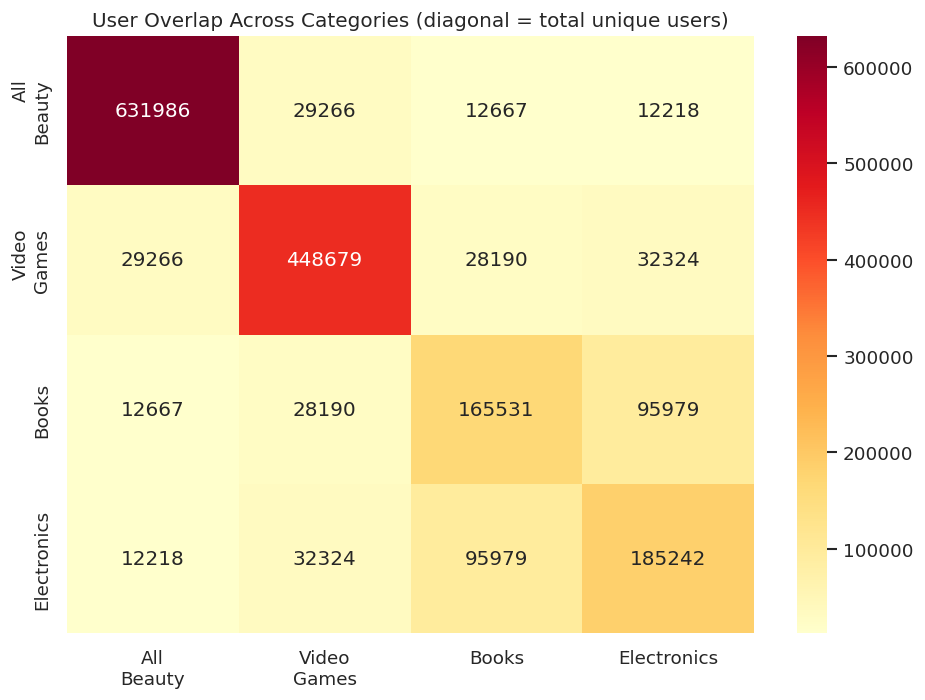

In [12]:
# Plot: Cross-category overlap heatmap
cats = list(cross_cat["category_user_counts"].keys())
n = len(cats)
overlap_matrix = np.zeros((n, n))
for i, ci in enumerate(cats):
    overlap_matrix[i, i] = cross_cat["category_user_counts"][ci]
    for j, cj in enumerate(cats):
        if i < j:
            key = (ci, cj)
            val = cross_cat["overlap_matrix"].get(key, 0)
            overlap_matrix[i, j] = val
            overlap_matrix[j, i] = val

fig, ax = plt.subplots(figsize=(8, 6))
# Normalize overlap by smaller category for readability
short_names = [c.replace("_", "\n") for c in cats]
sns.heatmap(overlap_matrix, annot=True, fmt=".0f", xticklabels=short_names,
            yticklabels=short_names, cmap="YlOrRd", ax=ax)
ax.set_title("User Overlap Across Categories (diagonal = total unique users)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "cross_category_overlap.png", bbox_inches="tight")
plt.show()

# Save results
with open(RESULTS_DIR / "cross_category_overlap.json", "w") as f:
    serializable = {
        "category_user_counts": cross_cat["category_user_counts"],
        "cross_category_distribution": {str(k): v for k, v in cross_cat["cross_category_distribution"].items()},
        "overlap_matrix": {f"{a}|{b}": v for (a, b), v in cross_cat["overlap_matrix"].items()},
        "n_total_unique_users": cross_cat["n_total_unique_users"],
    }
    json.dump(serializable, f, indent=2)

## Analysis 6: Rating & Engagement Distributions

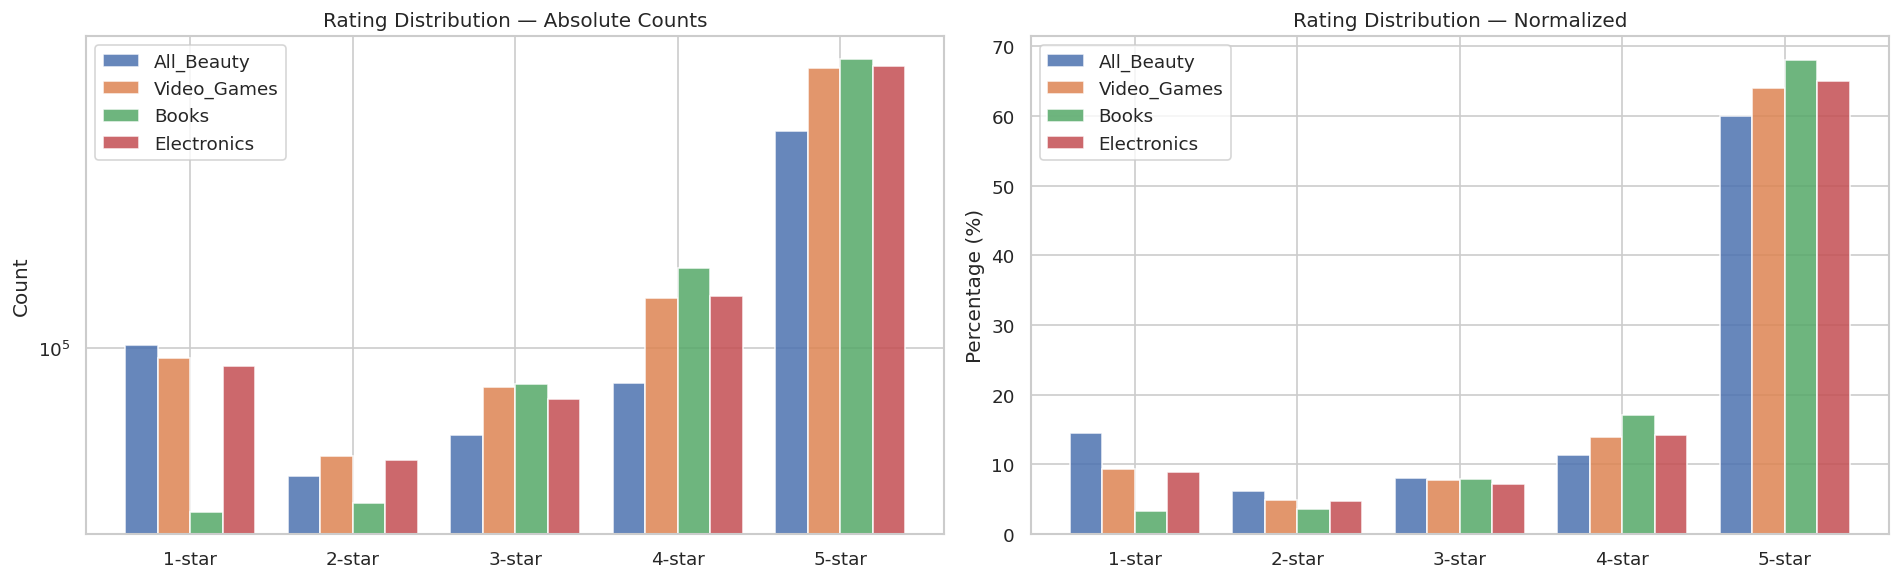

In [13]:
# Rating distribution per category (from streamed stats)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute counts
rating_labels = ["1-star", "2-star", "3-star", "4-star", "5-star"]
x = np.arange(5)
width = 0.2
for i, cat in enumerate(CATEGORIES):
    counts = all_stats[cat]["rating_hist"]
    axes[0].bar(x + i * width, counts, width, label=cat, alpha=0.85)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(rating_labels)
axes[0].set_ylabel("Count")
axes[0].set_title("Rating Distribution — Absolute Counts")
axes[0].legend()
axes[0].set_yscale("log")

# Normalized (% within category)
for i, cat in enumerate(CATEGORIES):
    counts = np.array(all_stats[cat]["rating_hist"], dtype=float)
    pcts = counts / counts.sum() * 100
    axes[1].bar(x + i * width, pcts, width, label=cat, alpha=0.85)
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(rating_labels)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Rating Distribution — Normalized")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "rating_distribution.png", bbox_inches="tight")
plt.show()

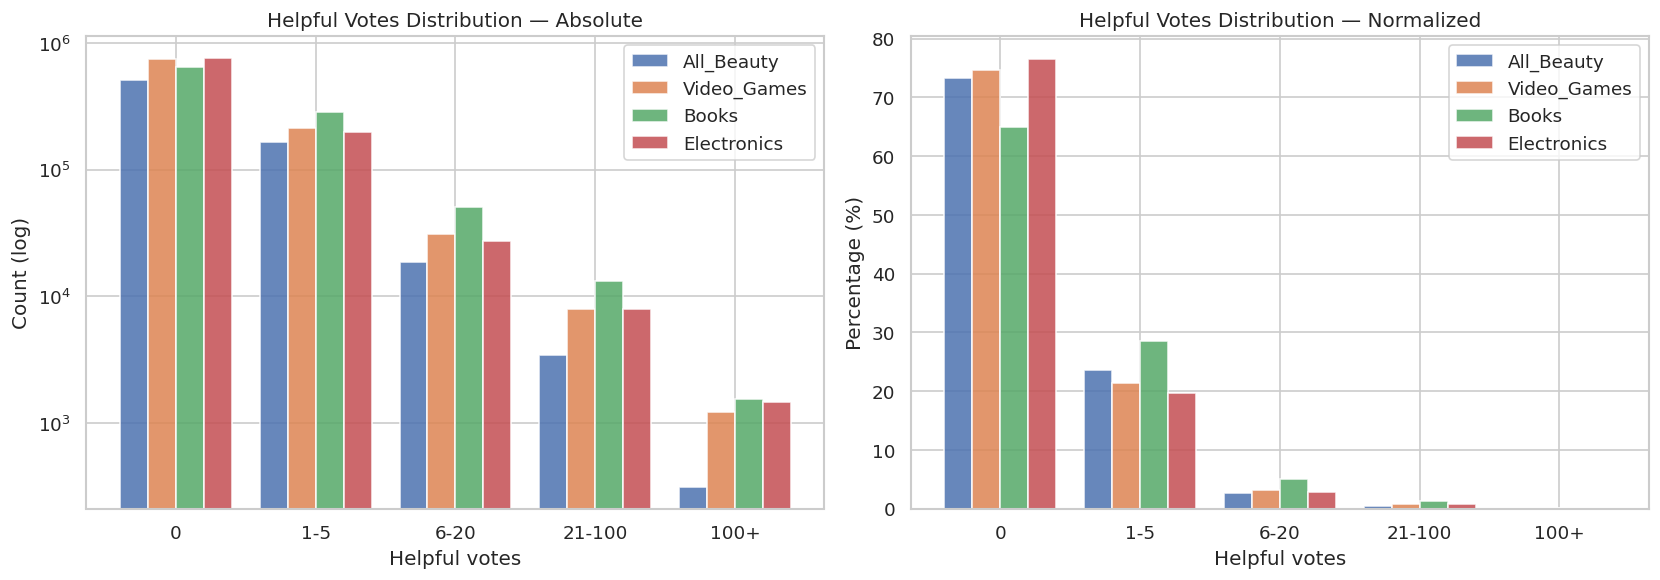

In [14]:
# Helpful votes distribution (from streamed stats)
hv_order = ["0", "1-5", "6-20", "21-100", "100+"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute
x = np.arange(len(hv_order))
for i, cat in enumerate(CATEGORIES):
    hv = all_stats[cat]["helpful_votes_hist"]
    counts = [hv.get(b, 0) for b in hv_order]
    axes[0].bar(x + i * width, counts, width, label=cat, alpha=0.85)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(hv_order)
axes[0].set_ylabel("Count (log)")
axes[0].set_yscale("log")
axes[0].set_xlabel("Helpful votes")
axes[0].set_title("Helpful Votes Distribution — Absolute")
axes[0].legend()

# Normalized
for i, cat in enumerate(CATEGORIES):
    hv = all_stats[cat]["helpful_votes_hist"]
    counts = np.array([hv.get(b, 0) for b in hv_order], dtype=float)
    pcts = counts / counts.sum() * 100
    axes[1].bar(x + i * width, pcts, width, label=cat, alpha=0.85)
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(hv_order)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xlabel("Helpful votes")
axes[1].set_title("Helpful Votes Distribution — Normalized")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "helpful_votes_distribution.png", bbox_inches="tight")
plt.show()

[load_sampled] Reading from /path/to/R-project/data/raw/All_Beauty/reviews.parquet


[load_sampled] Loaded 701,528 rows from All_Beauty
All_Beauty: Mean helpful votes by rating
            mean  median   count
rating                          
1.0     0.963852     0.0  102080
2.0     0.748339     0.0   43034
3.0     0.732005     0.0   56307
4.0     0.930550     0.0   79381
5.0     0.956071     0.0  420726


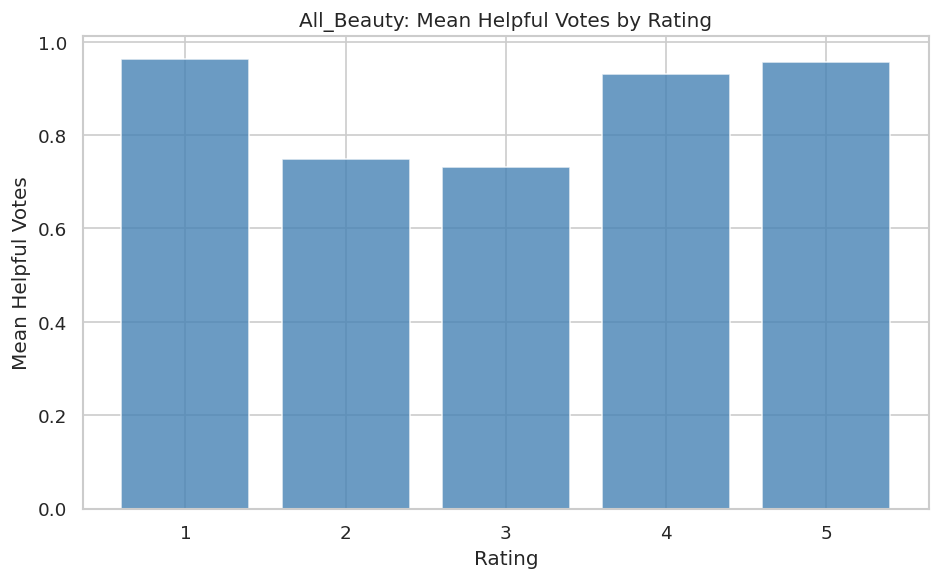

In [15]:
# Rating vs Helpful votes correlation (on sampled All_Beauty data)
df_beauty = load_sampled("All_Beauty")
fig, ax = plt.subplots(figsize=(8, 5))

# Group by rating, show helpful_vote stats
rating_hv = df_beauty.groupby("rating")["helpful_vote"].agg(["mean", "median", "count"])
print("All_Beauty: Mean helpful votes by rating")
print(rating_hv)

ax.bar(rating_hv.index, rating_hv["mean"], color="steelblue", alpha=0.8)
ax.set_xlabel("Rating")
ax.set_ylabel("Mean Helpful Votes")
ax.set_title("All_Beauty: Mean Helpful Votes by Rating")
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
fig.savefig(FIGURES_DIR / "rating_vs_helpful_votes.png", bbox_inches="tight")
plt.show()

---

## Analysis 7: Preprocessing Diagnostics

Run the full preprocessing pipeline on each category and report:
- Deduplication stats (how many duplicate user-item pairs)
- Missing value rates for item and user features
- Binary label distribution (rating >= 3 → positive)
- Feature store shapes
- Train/val/test split consistency

In [16]:
# Load pre-computed pipeline results from disk
# (Pipeline was run successfully via terminal — results saved under data/processed/)
import gc
for var in ['all_stats', 'df_beauty', 'cross_cat', 'filter_results', 'filter_df', 'bt_results']:
    if var in dir():
        exec(f'del {var}')
gc.collect()

from scripts.data.preprocessing_pipeline import PreprocessingPipeline
from scripts.data.loader import load_sampled, load_metadata

DATA_DIR = Path("/path/to/R-project/data")

pipelines = {}
for cat in CATEGORIES:
    processed_dir = DATA_DIR / "processed" / cat
    if processed_dir.exists():
        print(f"\n--- Loading saved results for {cat} ---")
        p = PreprocessingPipeline(cat)
        p.train_df = pd.read_parquet(processed_dir / "train.parquet")
        p.val_df = pd.read_parquet(processed_dir / "val.parquet")
        p.test_df = pd.read_parquet(processed_dir / "test.parquet")
        p.user_features = pd.read_parquet(processed_dir / "user_features.parquet")
        p.item_features = pd.read_parquet(processed_dir / "item_features.parquet")
        with open(processed_dir / "pipeline_stats.json") as f:
            p.all_stats = json.load(f)
        with open(processed_dir / "user_histories.json") as f:
            p.user_histories = json.load(f)
        # Load reviews_clean for the label distribution plot
        p.reviews_clean = pd.concat([p.train_df, p.val_df, p.test_df], ignore_index=True)
        # Load missing values report
        p.missing_values_report = {}
        for name in ["reviews", "metadata"]:
            mv_path = processed_dir / f"missing_values_{name}.csv"
            if mv_path.exists():
                p.missing_values_report[name] = pd.read_csv(mv_path, index_col=0)
        pipelines[cat] = p
        print(f"  Train: {len(p.train_df):,}, Val: {len(p.val_df):,}, Test: {len(p.test_df):,}")
        print(f"  User features: {p.user_features.shape}, Item features: {p.item_features.shape}")
    else:
        print(f"\n--- {cat}: no saved results, running pipeline ---")
        p = PreprocessingPipeline(cat)
        p.run()
        p.save()
        pipelines[cat] = p
    gc.collect()


--- Loading saved results for All_Beauty ---


  Train: 491,307, Val: 13,026, Test: 189,596
  User features: (631986, 9), Item features: (110566, 12)

--- Loading saved results for Video_Games ---


  Train: 804,201, Val: 51,671, Test: 134,604
  User features: (448679, 9), Item features: (130712, 9)

--- Loading saved results for Books ---


  Train: 916,965, Val: 30,873, Test: 49,660
  User features: (165531, 9), Item features: (468587, 9)

--- Loading saved results for Electronics ---


  Train: 901,907, Val: 38,065, Test: 55,573
  User features: (185242, 9), Item features: (1551350, 9)


In [17]:
# Deduplication summary
dedup_rows = []
for cat in CATEGORIES:
    s = pipelines[cat].all_stats["cleanup_reviews"]
    dedup_rows.append({
        "category": cat,
        "original": s["original_rows"],
        "after_dedup": s["after_dedup"],
        "duplicates_removed": s["duplicates_removed"],
        "dedup_rate": s["duplicates_removed"] / s["original_rows"],
        "unique_users": s["n_unique_users"],
        "unique_items": s["n_unique_items"],
    })
dedup_df = pd.DataFrame(dedup_rows).set_index("category")
print("Deduplication Summary")
dedup_df

Deduplication Summary


,original,after_dedup,duplicates_removed,dedup_rate,unique_users,unique_items
category,,,,,,
All_Beauty,701528,693929,7599,0.010832,631986,112565
Video_Games,1000000,990476,9524,0.009524,448679,81952
Books,1000000,997498,2502,0.002502,165531,504564
Electronics,1000000,995545,4455,0.004455,185242,271211


In [18]:
# Missing value rates — item metadata (most informative)
print("Metadata Missing Value Rates\n")
for cat in CATEGORIES:
    report = pipelines[cat].missing_values_report["metadata"]
    nonzero = report[report["null_rate"] > 0][["null_rate", "null_count"]]
    if len(nonzero) > 0:
        print(f"--- {cat} ---")
        print(nonzero.to_string())
        print()

Metadata Missing Value Rates

--- All_Beauty ---
                 null_rate  null_count
author            1.000000      110566
bought_together   1.000000      110566
subtitle          1.000000      110566
store             0.101207       11190

--- Video_Games ---
               null_rate  null_count
main_category   0.080505       10523
store           0.032254        4216

--- Books ---
               null_rate  null_count
store           0.021475       10063
main_category   0.000098          46

--- Electronics ---
               null_rate  null_count
main_category   0.065667      101873
store           0.005922        9187



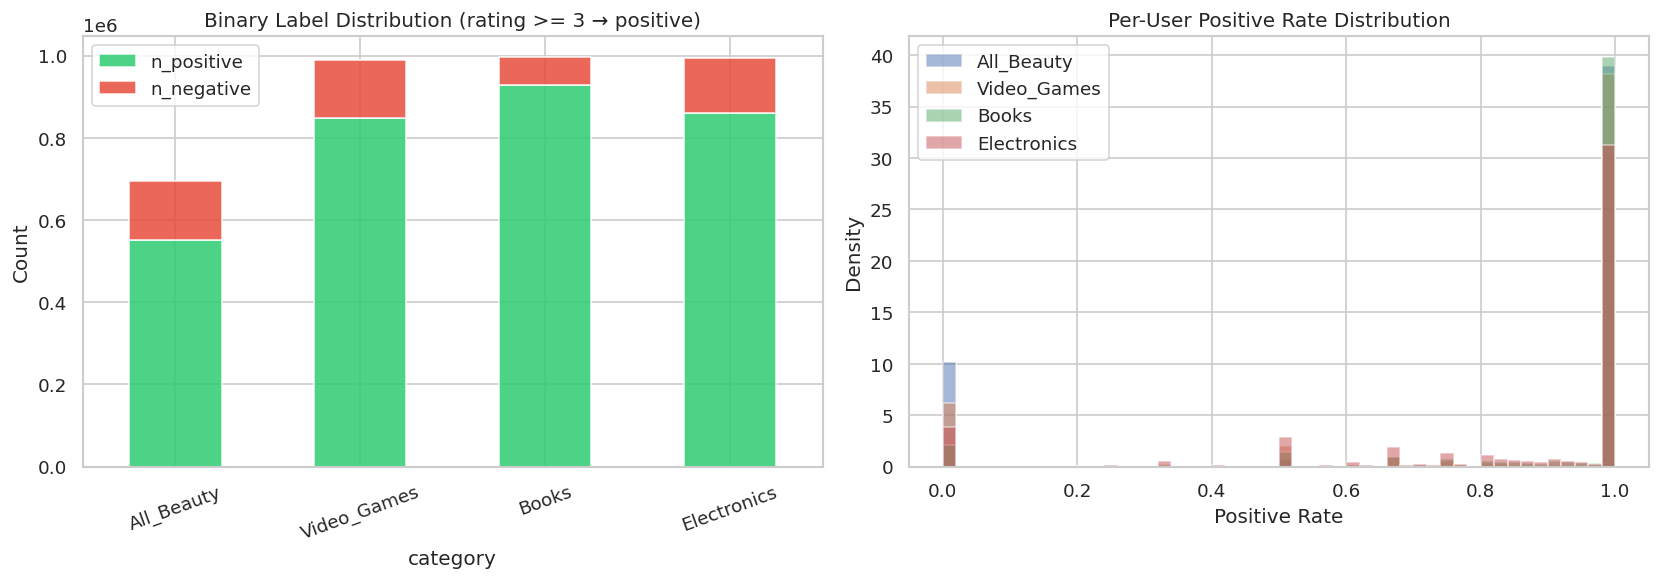


Label Summary


,positive_rate,n_positive,n_negative
category,,,
All_Beauty,0.793270,550473,143456
Video_Games,0.857070,848907,141569
Books,0.930236,927909,69589
Electronics,0.863222,859376,136169


In [19]:
# Binary label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall label distribution
label_rows = []
for cat in CATEGORIES:
    s = pipelines[cat].all_stats["labels"]
    label_rows.append({
        "category": cat,
        "positive_rate": s["positive_rate"],
        "n_positive": s["n_positive"],
        "n_negative": s["n_negative"],
    })
label_df = pd.DataFrame(label_rows).set_index("category")

label_df[["n_positive", "n_negative"]].plot(kind="bar", stacked=True, ax=axes[0],
                                              color=["#2ecc71", "#e74c3c"], alpha=0.85)
axes[0].set_title("Binary Label Distribution (rating >= 3 → positive)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)

# Per-user positive rate distribution
for cat in CATEGORIES:
    user_rates = pipelines[cat].reviews_clean.groupby("user_id")["label"].mean()
    axes[1].hist(user_rates, bins=50, alpha=0.5, label=cat, density=True)
axes[1].set_title("Per-User Positive Rate Distribution")
axes[1].set_xlabel("Positive Rate")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "label_distribution.png", bbox_inches="tight")
plt.show()

print("\nLabel Summary")
label_df

In [20]:
# Train/Val/Test split consistency
print("Split Consistency Check\n")
for cat in CATEGORIES:
    print(f"--- {cat} ---")
    consistency = pipelines[cat].all_stats["consistency"]
    rows = []
    for split_name, info in consistency.items():
        rows.append({
            "split": split_name,
            "n_rows": info["n_rows"],
            "n_users": info["n_users"],
            "n_items": info["n_items"],
            "label_rate": f"{info['label_positive_rate']:.4f}",
            "rating_mean": f"{info['rating_mean']:.3f}",
        })
    print(pd.DataFrame(rows).to_string(index=False))
    print()

Split Consistency Check

--- All_Beauty ---
split  n_rows  n_users  n_items label_rate rating_mean
train  491307   444818    96597     0.7945       3.963
  val   13026    13026     9531     0.8270       4.066
 test  189596   189596    58313     0.7879       3.946

--- Video_Games ---
split  n_rows  n_users  n_items label_rate rating_mean
train  804201   341863    75773     0.8612       4.193
  val   51671    51671    18509     0.8616       4.208
 test  134604   134604    31475     0.8306       4.109

--- Books ---
split  n_rows  n_users  n_items label_rate rating_mean
train  916965   137965   475216     0.9317       4.426
  val   30873    30873    25891     0.9233       4.481
 test   49660    49660    39077     0.9080       4.441

--- Electronics ---
split  n_rows  n_users  n_items label_rate rating_mean
train  901907   157643   256094     0.8672       4.227
  val   38065    38065    24726     0.8416       4.159
 test   55573    55573    31937     0.8140       4.065



In [21]:
# Feature store summary
print("Feature Store Summary\n")
for cat in CATEGORIES:
    p = pipelines[cat]
    print(f"--- {cat} ---")
    print(f"  User features: {p.user_features.shape[0]:,} users x {p.user_features.shape[1]} features")
    print(f"    Columns: {list(p.user_features.columns)}")
    print(f"  Item features: {p.item_features.shape[0]:,} items x {p.item_features.shape[1]} features")
    print(f"    Columns: {list(p.item_features.columns)}")
    print(f"  User histories: {len(p.user_histories):,} users with history")
    hist_lens = [len(v) for v in p.user_histories.values()]
    if hist_lens:
        print(f"    History length: mean={np.mean(hist_lens):.1f}, "
              f"median={np.median(hist_lens):.0f}, "
              f"P90={np.percentile(hist_lens, 90):.0f}, "
              f"max={max(hist_lens)}")
    print()

Feature Store Summary

--- All_Beauty ---
  User features: 631,986 users x 9 features
    Columns: ['n_reviews', 'avg_rating', 'std_rating', 'n_unique_items', 'active_days', 'n_verified', 'verified_rate', 'avg_helpful_vote', 'total_helpful_votes']
  Item features: 110,566 items x 12 features
    Columns: ['average_rating', 'rating_number', 'price', 'main_category', 'store', 'n_features', 'n_description', 'n_categories', 'has_bought_together', 'n_reviews_actual', 'avg_rating_actual', 'n_unique_reviewers']
  User histories: 444,818 users with history
    History length: mean=1.1, median=1, P90=1, max=164

--- Video_Games ---
  User features: 448,679 users x 9 features
    Columns: ['n_reviews', 'avg_rating', 'std_rating', 'n_unique_items', 'active_days', 'n_verified', 'verified_rate', 'avg_helpful_vote', 'total_helpful_votes']
  Item features: 130,712 items x 9 features
    Columns: ['average_rating', 'rating_number', 'price', 'main_category', 'store', 'has_bought_together', 'n_reviews_a

    History length: mean=2.4, median=1, P90=4, max=542

--- Books ---
  User features: 165,531 users x 9 features
    Columns: ['n_reviews', 'avg_rating', 'std_rating', 'n_unique_items', 'active_days', 'n_verified', 'verified_rate', 'avg_helpful_vote', 'total_helpful_votes']
  Item features: 468,587 items x 9 features
    Columns: ['average_rating', 'rating_number', 'price', 'main_category', 'store', 'has_bought_together', 'n_reviews_actual', 'avg_rating_actual', 'n_unique_reviewers']
  User histories: 137,965 users with history
    History length: mean=6.6, median=2, P90=13, max=3888

--- Electronics ---
  User features: 185,242 users x 9 features
    Columns: ['n_reviews', 'avg_rating', 'std_rating', 'n_unique_items', 'active_days', 'n_verified', 'verified_rate', 'avg_helpful_vote', 'total_helpful_votes']
  Item features: 1,551,350 items x 9 features
    Columns: ['average_rating', 'rating_number', 'price', 'main_category', 'store', 'has_bought_together', 'n_reviews_actual', 'avg_rat

    History length: mean=5.7, median=3, P90=12, max=1005

